<a href="https://colab.research.google.com/github/toobaidrees/Tooba_Idrees_Data_Analytics/blob/main/Phase%202%20Task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    roc_curve,
    auc
)

warnings.filterwarnings('ignore')

In [16]:
# Load Dataset
file_path = "Bank Marketing Dataset (UCI).xlsx"


In [20]:
from google.colab import files
uploaded = files.upload()

Saving Bank Marketing Dataset (UCI).xlsx to Bank Marketing Dataset (UCI).xlsx


In [21]:
import pandas as pd

df = pd.read_excel("Bank Marketing Dataset (UCI).xlsx")

In [22]:
import pandas as pd

df = pd.read_excel("Bank Marketing Dataset (UCI).xlsx")

In [23]:
import os
print(os.listdir())

['.config', 'Bank Marketing Dataset (UCI).xlsx', 'sample_data']


In [24]:
['bank.xlsx']

['bank.xlsx']

In [26]:
df = pd.read_excel("Bank Marketing Dataset (UCI).xlsx")

<Axes: xlabel='y', ylabel='count'>

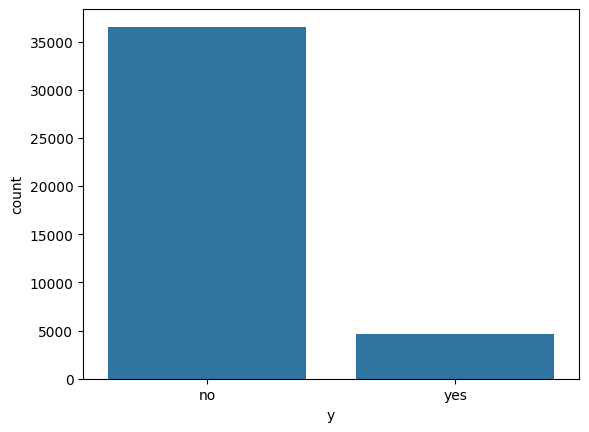

In [27]:
sns.countplot(x='y', data=df)

<Axes: >

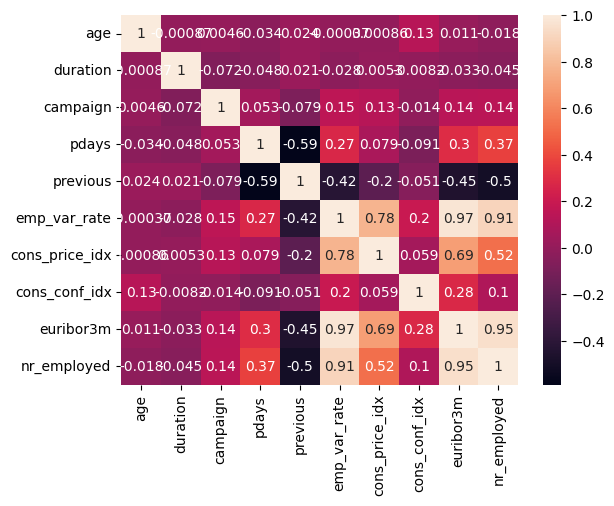

In [28]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [29]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [30]:
X = df.drop('y', axis=1)
y = df['y']

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

LogisticRegression()

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [35]:
lr_pred = lr.predict(X_test_scaled)
rf_pred = rf.predict(X_test)

In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)
print(cm)

[[7045  258]
 [ 456  479]]


In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      7303
           1       0.65      0.51      0.57       935

    accuracy                           0.91      8238
   macro avg       0.79      0.74      0.76      8238
weighted avg       0.91      0.91      0.91      8238

